# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The dataset I chose was the Flight Delay and Causes dataset from Kaggle https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes. The data includes flight level information such as departure/arrival times, origin and destination airports, delays, cancellation information, and delay cause categories (carrier delay, weather delay, National Aviation System delay, security delay, and late aircraft delay).

Who: My target audience would be airline operations managers, aiprort operation teams, or analysts responsible for reducing delays. 

What: Identify which delay types contribute most to total delays, which airports/routes appear most frequently in delayed flights, and wheteher certain times/days are associated with more delays. The goal is to support decisons on scheduling and opertional planning to reduce delays.  

How: I would start with summary charts showing distribution of arrival and departure delays to show the overall delay patterns. I would then try to create some graphs after I analyze the inital data to show any trends. 

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [3]:
#df_flight_dataset = pd.read_csv("flight_data.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
df_flight_dataset = pd.read_csv("flight_delay.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
#df_supply_chain_dataset.head()
#I chose to limit some of the columns of data so that I could see it all when I did my code . I limited to columns that would impact delivery
print(df_flight_dataset.describe())
#adjusted the format as it would cause errors for the median, mode, and median calculations. 
#df_delivery = df_flight_dataset[["Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Department Id","Order Item Quantity","Sales","Order Item Total","Product Status","shipping date (DateOrders)"]].copy()
#df_delivery["shipping date (DateOrders)"] = pd.to_datetime(df_delivery["shipping date (DateOrders)"], format='%m/%d/%Y', errors="coerce")
#df_delivery.describe()

         DayOfWeek      DepTime      ArrTime   CRSArrTime    FlightNum  \
count  9999.000000  9999.000000  9999.000000  9999.000000  9999.000000   
mean      3.883488  1556.362736  1603.452345  1623.224622  1982.533053   
std       1.742278   454.616055   590.990194   485.571315  2065.852940   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%       2.000000  1224.000000  1322.000000  1316.000000   380.000000   
50%       4.000000  1615.000000  1734.000000  1712.000000  1191.000000   
75%       5.000000  1923.000000  2044.000000  2012.000000  2726.000000   
max       7.000000  2400.000000  2400.000000  2359.000000  7694.000000   

       ActualElapsedTime  CRSElapsedTime      AirTime     ArrDelay  \
count        9999.000000     9999.000000  9999.000000  9999.000000   
mean          145.429443      142.641664   119.769077    65.732273   
std            87.431822       86.936230    84.543347    59.068532   
min            27.000000       20.000000     2.000000

Here I identify any other inconsistent data. 
Some inconsistent information I found are some of the shipping days scheduled and that are real have 0 day shipments which does not make sense. I also see a big outlier with benefit per order and order profit order with a value of -783, which I imagine should not be a negative value. I also found that there are no product descriptions and all the values in product status is 0. 

In [4]:
df_flight_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   DayOfWeek          9999 non-null   int64 
 1   Date               9999 non-null   object
 2   DepTime            9999 non-null   int64 
 3   ArrTime            9999 non-null   int64 
 4   CRSArrTime         9999 non-null   int64 
 5   UniqueCarrier      9999 non-null   object
 6   Airline            9999 non-null   object
 7   FlightNum          9999 non-null   int64 
 8   TailNum            9999 non-null   object
 9   ActualElapsedTime  9999 non-null   int64 
 10  CRSElapsedTime     9999 non-null   int64 
 11  AirTime            9999 non-null   int64 
 12  ArrDelay           9999 non-null   int64 
 13  DepDelay           9999 non-null   int64 
 14  Origin             9999 non-null   object
 15  Org_Airport        9957 non-null   object
 16  Dest               9999 non-null   object


In [5]:
#Identify if there are any duplicates 
#duplicate_rows = df_delivery.duplicated().sum()
#print(duplicate_rows)
#there are no duplicates within this dataset. 
df_flight_dataset.duplicated().sum()
#checked the rest of the column as well but no duplicates 

np.int64(0)

In [6]:
#Here I get the mean, median, and mode
df_flight = df_flight_dataset[["DepTime","ArrTime","Distance","TaxiIn","Cancelled","Diverted","CarrierDelay","WeatherDelay","LateAircraftDelay"]].copy()
df_mean = df_flight.mean()
df_mean

DepTime              1556.362736
ArrTime              1603.452345
Distance              843.138914
TaxiIn                  6.386739
Cancelled               0.000000
Diverted                0.000000
CarrierDelay           18.334433
WeatherDelay            2.327833
LateAircraftDelay      29.173417
dtype: float64

In [7]:
df_median = df_flight.median()
df_median

DepTime              1615.0
ArrTime              1734.0
Distance              599.0
TaxiIn                  5.0
Cancelled               0.0
Diverted                0.0
CarrierDelay            4.0
WeatherDelay            0.0
LateAircraftDelay      13.0
dtype: float64

In [8]:
df_mode = df_flight.mode()
df_mode


,DepTime,ArrTime,Distance,TaxiIn,Cancelled,Diverted,CarrierDelay,WeatherDelay,LateAircraftDelay
0,1812.0,2039,337.0,4.0,0.0,0.0,0.0,0.0,0.0
1,NaN,2209,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#Find null or na values
print(df_flight_dataset.isna().sum())
#print(df_supply_chain_dataset.isnull().sum())
#Missing values for order zipcode and product description
#converted the na values to 0 to show that they are missing values for the statistic. I did not remove the
#data as that would remove almost all the data. However for product description, it will not mattter with making those values 0 as all values were missing
df_flight_dataset.fillna(0)


DayOfWeek             0
Date                  0
DepTime               0
ArrTime               0
CRSArrTime            0
UniqueCarrier         0
Airline               0
FlightNum             0
TailNum               0
ActualElapsedTime     0
CRSElapsedTime        0
AirTime               0
ArrDelay              0
DepDelay              0
Origin                0
Org_Airport          42
Dest                  0
Dest_Airport         42
Distance              0
TaxiIn                0
TaxiOut               0
Cancelled             0
CancellationCode      0
Diverted              0
CarrierDelay          0
WeatherDelay          0
NASDelay              0
SecurityDelay         0
LateAircraftDelay     0
dtype: int64


,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,3/1/2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,3/1/2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,3/1/2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,3/1/2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,3/1/2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,4,24-01-2019,1651,1953,1927,US,US Airways Inc.,1459,N171US,362,...,4,22,0,N,0,0,0,26,0,0
9995,4,24-01-2019,1134,1552,1415,US,US Airways Inc.,1297,N917UW,198,...,4,15,0,N,0,97,0,0,0,0
9996,4,24-01-2019,1455,1642,1613,US,US Airways Inc.,907,N103US,107,...,3,16,0,N,0,0,0,4,0,25
9997,4,24-01-2019,1142,1342,1319,US,US Airways Inc.,1021,N186US,120,...,3,26,0,N,0,12,0,11,0,0


In [10]:
#Using one hot encoding to adjust some of the category of data

#Adjusted the shipping mode to use ints 
unique=df_flight_dataset["Org_Airport"].unique
df_flight_fixed = df_flight_dataset
one_hot = pd.get_dummies(df_flight_dataset["Org_Airport"], dtype=int)
df_flight_fixed = df_flight_dataset.join(one_hot)
df_flight_fixed.iloc[0:5]

#Adjusted the delivery status to use ints 
#df_supply_fixed = df_supply_chain_dataset.drop(columns=df_supply_chain_dataset["Delivery Status"].unique(), errors="ignore")
#one_hot = pd.get_dummies(df_supply_chain_dataset["Delivery Status"], dtype=int)
#df_supply_fixed = df_supply_chain_dataset.join(one_hot)
#df_supply_fixed.iloc[0:5]




,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Valley International Airport,Washington Dulles International Airport,Westchester County Airport,Wichita Dwight D. Eisenhower National AirportÂ (Wichita Mid-Continent Airport),Will Rogers World Airport,William P. Hobby Airport,Wilmington International Airport,Yampa Valley AirportÂ (Yampa Valley Regional),Yellowstone Regional Airport,Yuma International Airport
0,4,3/1/2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,0,0,0,0,0,0,0,0,0,0
1,4,3/1/2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,0,0,0,0,0,0,0,0,0,0
2,4,3/1/2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,0,0,0,0,0,0,0,0,0,0
3,4,3/1/2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,0,0,0,0,0,0,0,0,0,0
4,4,3/1/2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,0,0,0,0,0,0,0,0,0,0


In [12]:
#Check for categorical imbalances

#asked google how to check the values of a column of  data with panda dataframe using python
tailnum_mode = df_flight_dataset["TailNum"].value_counts(dropna=False)
print(tailnum_mode)
counts_taxiout = df_flight_dataset["TaxiOut"].value_counts(dropna=False)
print(counts_taxiout)
cancellation_code = df_flight_dataset["Org_Airport"].value_counts(dropna=False)
print(cancellation_code)

TailNum
N326UA    30
N582SW    28
N381UA    28
N294SW    27
N229SW    27
          ..
N308AW     1
N452SW     1
N802SK     1
N583SW     1
N307AW     1
Name: count, Length: 1453, dtype: int64
TaxiOut
13     632
11     615
12     615
10     611
15     556
      ... 
141      1
124      1
131      1
98       1
117      1
Name: count, Length: 121, dtype: int64
Org_Airport
Chicago O'Hare International Airport               1183
San Francisco International Airport                 903
Denver International Airport                        848
Los Angeles International Airport                   594
Charlotte Douglas International Airport             533
                                                   ... 
Valley International Airport                          1
Great Falls International Airport                     1
Charleston International Airport/Charleston AFB       1
Akron-Canton Regional Airport                         1
Central Wisconsin Airport                             1
Name: count, 

Conclusion
- Are the data usable?  If not, find some new data! 
The dataset is usable for exploratory analysis of flight operations and delays. The dataset has numerous rows and columns with a mix of numeric data and string data like ariline and airports. Most columns show non-null values so no major missing data. 

- Do you need to modify or correct the data in some way?
I did not modify or correct the data but the time fileds (DepTime and ArrTime) should be adjusted to represent clock time as they are formated as an int. Based on the checks there was no missing or duplicate values. 

- Is there any class imbalance?  (Categories that have many more items than other categories).
There was some imbalance with the data I collected as I was only able to put 10000 datapoints as python was not able to handle the full dataset. The cancellationCode was almost dominated by one single value in the output showed. The TailNum alsow shoed up many times compared to other aircrafts. 

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

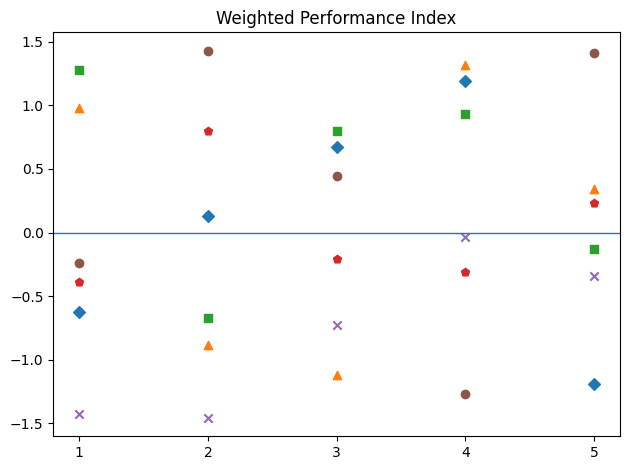

In [ ]:
#I will attempt to create teh weighted performance index 

import matplotlib.pyplot as plt

competitors = ["Our Business", "Competitor A", "Competitor B", "Competitor C", "Competitor D", "Competitor E"]
categories = ["1","2","3","4","5"]
x= np.arange(len(categories))
#create arrays for each competitor

data = {
    "Our Business": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor A": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor B": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor C": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor D": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor E": np.random.uniform(-1.50, 1.50, size = 5)
} 

#Due ot this being a dictionary so I will have to separate the x and y values
x_values=[]
y_values=[]


markers = {
    "Our Business": "D",
    "Competitor A": "^",
    "Competitor B": "s",
    "Competitor C": "p",
    "Competitor D": "x",
    "Competitor E": "o"
} 


for comp, y in data.items():
    plt.scatter(x, y, marker = markers[comp], label=comp)


plt.title("Weighted Performance Index")
plt.xticks(x, categories)
plt.axhline(0, linewidth=1)
#plt.legend()

plt.tight_layout()
